# Hito 3 - Explicabilidad del Modelo con SHAP
## GuardianAI - Deteccion Inteligente de Fraude Bancario

## Indice

1. Importacion de librerias
2. Carga del modelo final de produccion (NB05)
   - 2.1. Carga del modelo y preprocesador persistidos
   - 2.2. Reconstruccion del conjunto de test
3. Que es SHAP y por que se usa
4. Calculo de valores SHAP
5. Interpretacion global: Summary Plot
6. Interpretacion local: Waterfall Plot
7. Contexto de resultados y analisis critico
8. Conclusiones del analisis de explicabilidad

## 1. Importacion de librerias

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split

# Utilidades comunes del proyecto (ver src/config.py y src/evaluation.py)
import config
from config import (
    DATA_PATH, MODELS_DIR, FIGURES_DIR,
    RANDOM_STATE, TEST_SIZE, VAL_SIZE,
    DTYPE_BASE_CSV,
)
from evaluation import cargar_artefactos

config.set_global_seeds(RANDOM_STATE)
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

print(f'MODELS_DIR  = {MODELS_DIR}')
print(f'FIGURES_DIR = {FIGURES_DIR}')

MODELS_DIR  = C:\Users\al3xc\Desktop\MASTER\DISIA\repositorios\GuardianAI\models
FIGURES_DIR = C:\Users\al3xc\Desktop\MASTER\DISIA\repositorios\GuardianAI\figures


## 2. Carga del modelo final de produccion (NB05)

Este notebook explica el **modelo final de produccion** entrenado y persistido en `05_final_model_production.ipynb` (NB05). Ese modelo es un `XGBoost` con manejo de desbalanceo via `scale_pos_weight` (**sin SMOTE**) cuyos hiperparametros se optimizaron con `RandomizedSearchCV` (30 iteraciones x 3-fold CV).

A diferencia de versiones anteriores de este notebook, aqui **no se reentrena ningun modelo**. Se cargan los artefactos ya entrenados desde `models/` (`modelo_final.joblib`, `preprocesador.joblib`, `metadatos.json`) y se aplica SHAP directamente sobre el test real desbalanceado. Esta separacion entrenamiento / explicabilidad refleja como funcionaria el sistema en produccion.

### 2.1. Carga del modelo y preprocesador persistidos

In [2]:
artefactos = cargar_artefactos(MODELS_DIR)

if 'modelo' not in artefactos or 'preprocesador' not in artefactos:
    raise FileNotFoundError(
        f'No se encontraron los artefactos en {MODELS_DIR}.\n'
        'Ejecuta primero 05_final_model_production.ipynb para generarlos.'
    )

modelo_final  = artefactos['modelo']
preprocesador = artefactos['preprocesador']
metadatos     = artefactos.get('metadatos', {})

print('Modelo cargado:        ', type(modelo_final).__name__)
print('Preprocesador cargado: ', type(preprocesador).__name__)

if metadatos:
    m = metadatos.get('metricas_test', {})
    print('\nMetricas reportadas por NB05 sobre test real desbalanceado:')
    print(f"  F1:      {m.get('f1')}")
    print(f"  PR-AUC:  {m.get('pr_auc')}")
    print(f"  ROC-AUC: {m.get('roc_auc')}")
    print(f"  Umbral:  {m.get('umbral_optimo')}")

Modelo cargado:         XGBClassifier
Preprocesador cargado:  ColumnTransformer

Metricas reportadas por NB05 sobre test real desbalanceado:
  F1:      0.249
  PR-AUC:  0.183
  ROC-AUC: 0.899
  Umbral:  0.9177


### 2.2. Reconstruccion del conjunto de test

El preprocesador ya esta `fit` con el train de NB05, asi que basta con recrear exactamente la misma particion 70/15/15 estratificada (mismo `random_state=42`) y aplicarle `transform`. Esto garantiza que las explicaciones SHAP se calculan sobre los mismos registros que se usaron para reportar las metricas finales.

In [3]:
df = pd.read_csv(DATA_PATH, dtype=DTYPE_BASE_CSV)
X = df.drop(columns=['fraud_bool'])
y = df['fraud_bool']

# Split identico al de NB05 (70/15/15 estratificado, random_state=42)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE,
)
val_relativo = VAL_SIZE / (1 - TEST_SIZE)
_, _, _, _ = train_test_split(
    X_train_val, y_train_val,
    test_size=val_relativo, stratify=y_train_val, random_state=RANDOM_STATE,
)

# Preprocesar el test con el ColumnTransformer ya ajustado en NB05
X_test_pre = preprocesador.transform(X_test)

# Nombres de features tras el OneHotEncoder (para que SHAP los muestre legibles)
feature_names = list(preprocesador.get_feature_names_out())
X_test_df = pd.DataFrame(X_test_pre, columns=feature_names)

print(f'Test reconstruido: {X_test_df.shape[0]:,} filas x {X_test_df.shape[1]} variables')
print(f'Prevalencia de fraude en test: {y_test.mean()*100:.2f} %')

Test reconstruido: 150,000 filas x 52 variables
Prevalencia de fraude en test: 1.10 %


## 3. Que es SHAP y por que se usa

XGBoost combina cientos de arboles de decision para hacer sus predicciones. Eso lo hace muy potente, pero tambien muy dificil de entender: no es posible saber a simple vista por que el modelo decide que una solicitud concreta es un fraude. En el sector bancario esto es un problema serio: la regulacion europea (GDPR) exige que las decisiones automatizadas que afectan a personas sean explicables y auditables.

**SHAP** (SHapley Additive exPlanations) resuelve esto aplicando un concepto de la teoria de juegos llamado **valores de Shapley**. La idea es sencilla: imagina que cada variable del modelo es un jugador en un equipo, y la prediccion final es el resultado del equipo. Los valores de Shapley calculan cuanto ha contribuido cada jugador al resultado, probando todas las combinaciones posibles de jugadores y midiendo cuanto cambia el resultado al incluir o excluir cada uno.

En la practica, cada prediccion se descompone asi:

```
prediccion = valor_base + contribucion(var_1) + contribucion(var_2) + ...
```

donde el `valor_base` es la probabilidad media de fraude en el dataset, y cada contribucion puede ser positiva (empuja hacia fraude) o negativa (empuja hacia legitima).

**Por que SHAP y no la importancia de Gini de XGBoost:**

- La importancia de Gini dice *cuanto* usa el modelo una variable en promedio, pero no dice *en que direccion* ni *en que casos concretos*.
- SHAP da tanto la magnitud como la direccion de cada variable, tanto a nivel global (comportamiento promedio del modelo) como local (explicacion de una prediccion individual).
- SHAP tiene base matematica solida: es la unica forma de distribuir el credito entre variables que cumple simultaneamente eficiencia, simetria y linealidad - propiedades matematicamente deseables para una explicacion justa.

Para XGBoost se usa `TreeExplainer`, que aprovecha la estructura de los arboles para calcular los valores SHAP exactos de forma eficiente, sin necesidad de aproximaciones.

## 4. Calculo de valores SHAP

Calcular SHAP sobre las 150.000 filas del test completo seria muy lento. Se toma una muestra aleatoria representativa de **1.000 filas** del test, suficiente para que los patrones globales sean estables. Esta practica es estandar cuando el dataset es grande.

El conjunto de test conserva el desbalanceo original (~1.1 % de fraudes), por lo que la muestra contiene relativamente pocos fraudes reales. Para los graficos globales eso no es un problema porque SHAP analiza las contribuciones de las variables independientemente de la clase real. Para el waterfall plot se seleccionara especificamente una muestra con probabilidad alta de fraude.

In [4]:
N_MUESTRA = 1000
np.random.seed(RANDOM_STATE)
indices_muestra = np.random.choice(len(X_test_df), size=N_MUESTRA, replace=False)
indices_muestra = np.sort(indices_muestra)

X_shap = X_test_df.iloc[indices_muestra].reset_index(drop=True).astype(np.float32)
print(f'Muestra para SHAP: {X_shap.shape[0]} filas x {X_shap.shape[1]} variables')

# TreeExplainer: version rapida especifica para modelos basados en arboles
explainer = shap.TreeExplainer(modelo_final)
shap_vals = explainer.shap_values(X_shap, check_additivity=False)

print('Valores SHAP calculados correctamente.')
print(f'Forma de la matriz SHAP: {shap_vals.shape}')
print('(filas = muestras, columnas = variables, valores = contribucion a la prediccion)')

Muestra para SHAP: 1000 filas x 52 variables
Valores SHAP calculados correctamente.
Forma de la matriz SHAP: (1000, 52)
(filas = muestras, columnas = variables, valores = contribucion a la prediccion)


## 5. Interpretacion global: Summary Plot

El summary plot muestra el comportamiento global del modelo: que variables usa mas y en que direccion.

**Como leer este grafico:**

- Las variables aparecen ordenadas de mayor a menor importancia media (la variable que mas influye en las predicciones va arriba).
- Cada punto representa una muestra del test. Su posicion horizontal indica el valor SHAP de esa variable para esa muestra: positivo significa que esa variable empuja la prediccion hacia fraude, negativo significa que la empuja hacia legitima.
- El color del punto indica el valor real de la variable en esa muestra: rojo = valor alto, azul = valor bajo.
- Una nube de puntos ancha indica que el impacto de esa variable varia mucho segun el caso concreto.

Por ejemplo: si `keep_alive_session` aparece arriba y sus puntos rojos estan a la derecha, significa que tener la sesion activa (valor alto) aumenta la probabilidad de fraude segun el modelo.

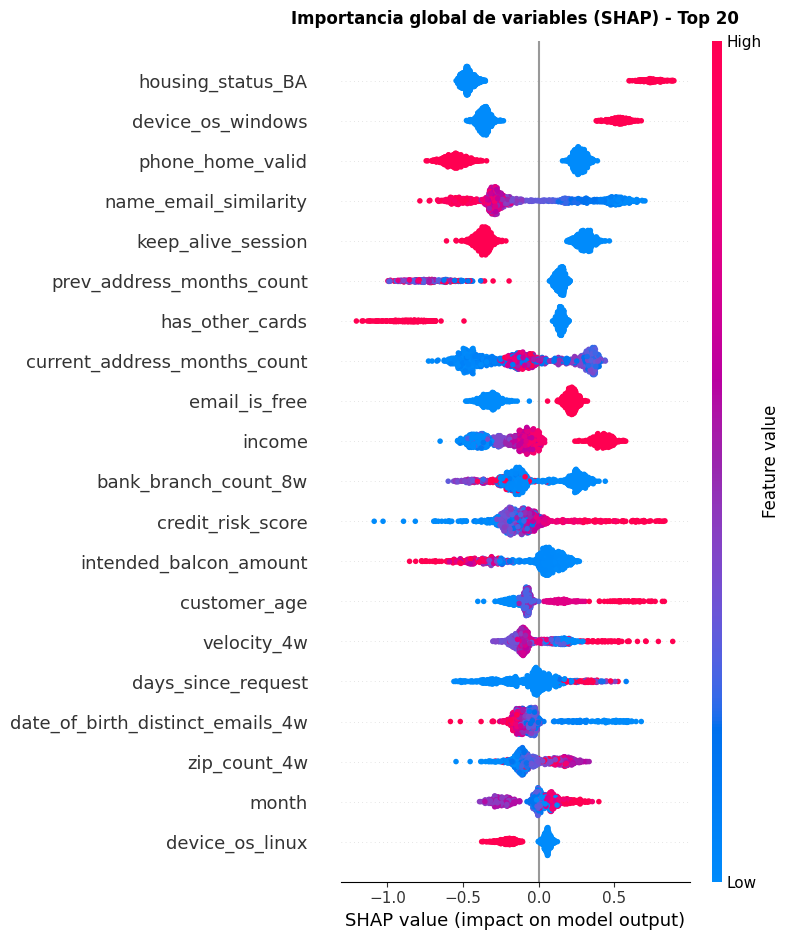

In [5]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals, X_shap,
    max_display=20,
    show=False,
)
plt.title('Importancia global de variables (SHAP) - Top 20',
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'shap_summary_dot.png'), dpi=150, bbox_inches='tight')
plt.show()

El grafico de puntos anterior muestra la direccion de cada variable. A continuacion, el grafico de barras resume la importancia media absoluta de cada variable, mas sencillo de leer para comparar magnitudes:

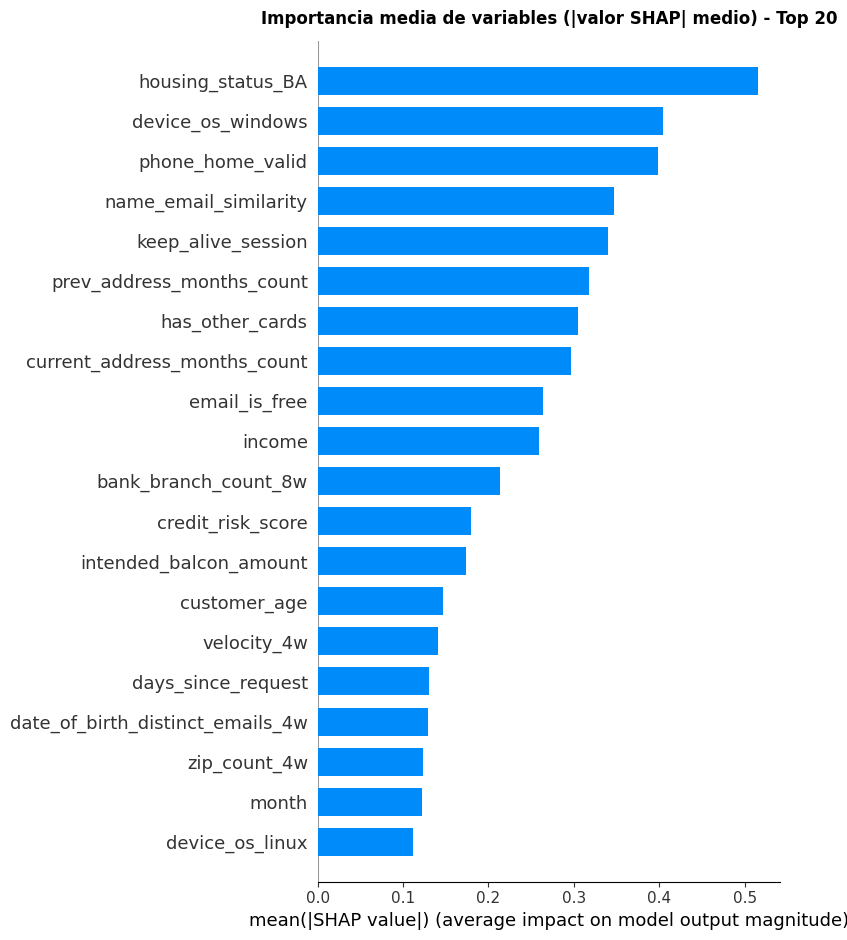

In [6]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals, X_shap,
    plot_type='bar',
    max_display=20,
    show=False,
)
plt.title('Importancia media de variables (|valor SHAP| medio) - Top 20',
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'shap_summary_bar.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Interpretacion local: Waterfall Plot

El summary plot explica el comportamiento promedio del modelo. El waterfall plot explica **una prediccion individual concreta**: por que el modelo decidio que esa solicitud especifica era un fraude.

Esto es especialmente util en banca: si un cliente reclama que se le ha bloqueado injustamente, el analista puede ver exactamente que variables activaron la alerta y con que intensidad.

**Como leer este grafico:**

- La barra arranca en el `valor base` (probabilidad media de fraude en el dataset completo).
- Cada variable suma o resta su contribucion SHAP a ese valor base.
- Las barras rojas empujan hacia fraude (contribucion positiva).
- Las barras azules empujan hacia legitima (contribucion negativa).
- El resultado final es la probabilidad predicha para ese caso concreto.

Se selecciona la muestra con mayor probabilidad de fraude predicha para que la explicacion sea mas ilustrativa.

In [7]:
# Predicciones sobre la muestra
y_prob_muestra = modelo_final.predict_proba(X_shap)[:, 1]

# Usar la muestra con mayor probabilidad de fraude
idx_local = int(np.argmax(y_prob_muestra))
print(f'Muestra seleccionada: indice {idx_local}')
print(f'Probabilidad de fraude predicha: {y_prob_muestra[idx_local]:.4f}')

Muestra seleccionada: indice 991
Probabilidad de fraude predicha: 0.9883


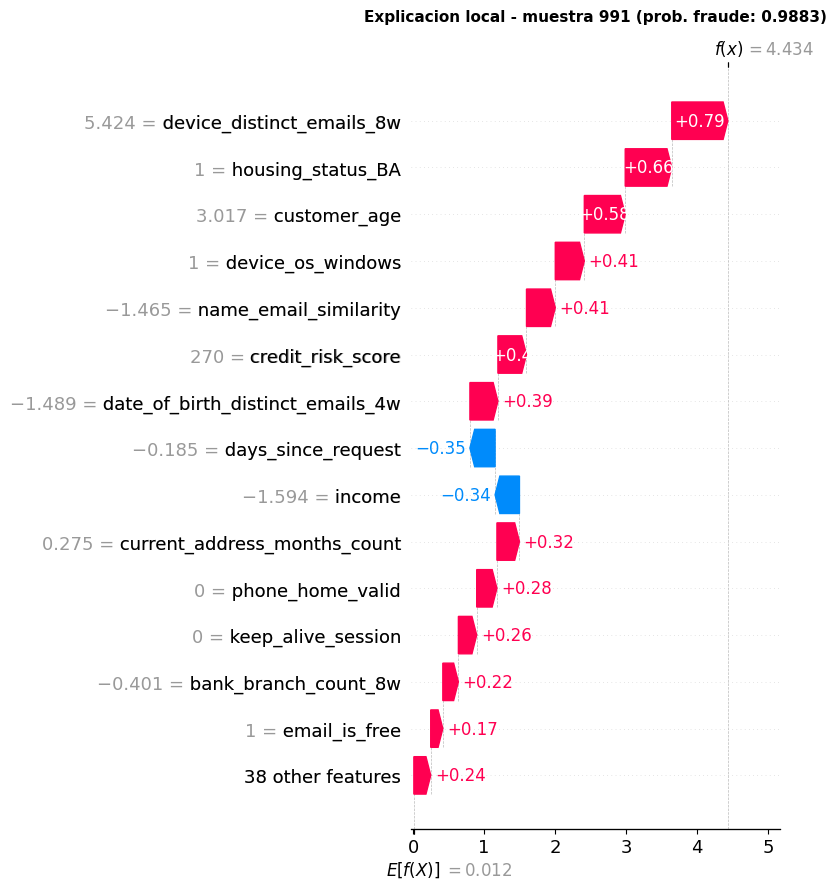

In [8]:
# Calcular la explicacion SHAP estructurada para esa muestra concreta
explicacion = explainer(X_shap, check_additivity=False)

plt.figure()
shap.plots.waterfall(explicacion[idx_local], max_display=15, show=False)
plt.title(
    f'Explicacion local - muestra {idx_local} '
    f'(prob. fraude: {y_prob_muestra[idx_local]:.4f})',
    fontsize=11, fontweight='bold', pad=12,
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'shap_waterfall.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Contexto de resultados y analisis critico

### Resultados globales del proyecto

Antes de interpretar SHAP es importante situar el rendimiento real del modelo en el contexto de todo el trabajo realizado:

| Notebook | Modelo | F1 | PR-AUC | ROC-AUC | Nota |
|----------|--------|-----|--------|---------|------|
| NB02 | XGBoost (sin SMOTE) | 0.2359 | 0.1711 | 0.8944 | Baseline inicial |
| NB02 | Reg. Logistica | 0.2110 | 0.1363 | 0.8755 | |
| NB02 | GNN | 0.2060 | 0.1333 | 0.8710 | 1527 s de entrenamiento |
| NB02 | Random Forest | 0.1956 | 0.1243 | 0.8768 | |
| NB02 | LSTM | 0.1183 | 0.0593 | 0.7998 | |
| NB03 | XGBoost opt. + SMOTE | 0.1912 | 0.1174 | 0.8730 | SMOTE degrada |
| NB03 | RF opt. + SMOTE | 0.1652 | 0.0910 | 0.8551 | |
| NB03 | LR opt. + SMOTE | 0.1653 | 0.0816 | 0.8316 | |
| **NB05** | **XGBoost opt. + scale_pos_weight (sin SMOTE)** | **0.2490** | **0.1830** | **0.8990** | **Modelo analizado aqui** |

**Observacion clave**: el modelo de NB05 (XGBoost con `scale_pos_weight` y optimizacion de hiperparametros, **sin SMOTE**) es el mejor resultado del proyecto. Supera al XGBoost simple de NB02 en las tres metricas principales y, sobre todo, al XGBoost con SMOTE de NB03 (F1 +30 %, PR-AUC +56 %). Este es el modelo que se persiste en `models/` y se explica en este notebook.

### Por que SMOTE no mejoro (y por que `scale_pos_weight` si)

Bank Account Fraud (NeurIPS 2022) es un dataset **sintetico**: sus datos fueron generados artificialmente a partir de patrones de datos bancarios reales, no son transacciones bancarias reales. Cuando SMOTE genera muestras sinteticas interpolando entre muestras ya sinteticas, introduce una doble artificialidad que anade ruido en lugar de informacion util. El parametro `scale_pos_weight` de XGBoost, en cambio, reequilibra las clases *reponderando el gradiente* sin inventar datos nuevos, lo que resulta mas efectivo en este dataset.

Este resultado es un hallazgo valido del proyecto: demuestra que SMOTE no es una solucion universal y que su eficacia depende de la naturaleza de los datos.

### Por que los resultados absolutos son bajos

Detectar ~32 % de los fraudes con una precision del ~20 % puede parecer modesto, pero es lo esperable con datos tabulares sinteticos sin informacion temporal. Los sistemas de deteccion de fraude en produccion real combinan:

- **Datos temporales**: secuencias de transacciones, velocidades de cambio en el comportamiento del usuario a lo largo del tiempo.
- **Grafos de relaciones**: conexiones entre cuentas, dispositivos y geolocalizaciones que permiten detectar redes de fraude organizadas.
- **Calibracion del umbral al coste de negocio**: en banca, bloquear un fraude de 5.000 EUR puede justificar generar hasta 20 falsas alarmas si el coste de cada falsa alarma (gestion manual) es de 200 EUR.
- **Retroalimentacion continua**: el modelo se reentrena frecuentemente con los fraudes confirmados mas recientes.

Nada de esto es posible con este dataset. El valor del trabajo es metodologico, no en los numeros absolutos.

### Sobre los valores SHAP con este modelo

SHAP explica *lo que hace el modelo*, no *lo que deberia hacer*. Las variables que aparecen como mas importantes son aquellas en las que el modelo se apoya para tomar sus decisiones - correctas o no. Con un F1 de 0.2490 el modelo todavia acierta menos de lo ideal, y SHAP nos muestra los patrones de esas decisiones, incluyendo los errores.

Dicho esto, si los patrones que muestra SHAP tienen sentido desde el punto de vista del negocio bancario (las variables mas importantes son realmente indicadores razonables de fraude), eso es una validacion cualitativa de que el modelo ha aprendido algo real, aunque le quede margen de mejora.

## 8. Conclusiones del analisis de explicabilidad

El analisis SHAP cumple dos funciones en el sistema GuardianAI:

**A nivel global** (summary plot), permite identificar que variables son las mas influyentes y en que direccion actuan. Esto sirve para validar cualitativamente que el modelo ha aprendido patrones con sentido de negocio: si las variables mas importantes son indicadores logicos de comportamiento fraudulento, el modelo esta aprendiendo algo real aunque sus metricas cuantitativas sean modestas.

**A nivel local** (waterfall plot), permite explicar cualquier prediccion individual de forma trazable. Esto satisface dos requisitos criticos:

- **Regulatorio**: el GDPR exige que las decisiones automatizadas que afectan a personas sean explicables y auditables. Un sistema que solo devuelve una probabilidad sin explicacion no cumple este requisito.
- **Operativo**: los analistas de riesgo pueden revisar los casos limite con contexto real, en lugar de basarse ciegamente en un numero.

### Coherencia con el modelo de produccion

A diferencia de versiones anteriores de este notebook, aqui se analiza **exactamente el mismo modelo que se reporta en la seccion de resultados finales** (NB05, F1 = 0.2490, PR-AUC = 0.1830, ROC-AUC = 0.8990). Cargarlo desde disco via `joblib.load` en lugar de reentrenarlo aqui tiene dos ventajas: (1) garantiza que la explicabilidad y las metricas estan referidas al mismo artefacto, y (2) reproduce el flujo que tendria el sistema en produccion, donde el entrenamiento y la inferencia / explicabilidad estan desacoplados.

### Limitaciones identificadas

1. SHAP explica el modelo actual. Si en iteraciones futuras el modelo mejora sustancialmente (por ingenieria de caracteristicas, datos temporales o arquitecturas mas sofisticadas), el analisis SHAP cambiara.
2. La muestra de 1.000 casos es representativa estadisticamente, pero los patrones del summary plot pueden variar ligeramente con muestras distintas. Para un analisis en produccion se usarian al menos 5.000-10.000 muestras.
3. Los nombres de las features tras el `ColumnTransformer` pueden aparecer con prefijos del tipo `num__`, `cat__` o con el sufijo de la categoria one-hot. Eso hace el grafico un poco mas verboso pero permite distinguir exactamente que transformacion se aplico a cada variable.

### Aplicacion en el Hito 4 (despliegue con FastAPI)

La integracion natural de SHAP en produccion seria devolver, junto a cada prediccion de la API, las 3-5 variables que mas influyeron en esa decision concreta y en que sentido. Por ejemplo:

```json
{
  "probabilidad_fraude": 0.73,
  "decision": "ALERTA",
  "explicacion": [
    {"variable": "keep_alive_session", "direccion": "fraude", "peso": 0.31},
    {"variable": "velocity_6h",        "direccion": "fraude", "peso": 0.18},
    {"variable": "income",              "direccion": "legitima","peso": -0.09}
  ]
}
```

Eso convierte el sistema en algo auditable y util en la practica, independientemente de las limitaciones actuales de las metricas.